# Laboratorio 5 - Cobertura Hospitalaria Espacial en Iowa

Se construye un modelo espacial de cobertura hospitalaria para **Iowa** (134 hospitales en los datos). Se responden dos preguntas:

- ¿Qué fracción de la población tiene un hospital a una distancia razonable?
- ¿Dónde están las brechas más críticas?

**Configuración de entorno**

Primero se importan las librerías y se definen las constantes del estado.

In [1]:
import os
import urllib.request

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmium
import osmnx as ox
import pandas as pd
from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar
from requests.exceptions import RequestException

pd.set_option("display.float_format", "{:,.2f}".format)

DATA = "data/"
ESTADO = "IA"           # Iowa
COD_ESTADO = "19"       # código FIPS de Iowa
CRS_PROY = "EPSG:26915" # NAD83 / UTM zona 15N (metros)

## Task 1 — Preparación de datos, estadísticas y buffers

### Task 1.1. Carga y preparación

#### a) Carga de los cuatro archivos

Se leen las capas geográficas con `gpd.read_file` y la tabla de población con `pd.read_csv`. Para cada archivo se reportan registros, CRS y columnas.

In [2]:
hospitales = gpd.read_file(DATA + "hospitales_eeuu.geojson")
condados = gpd.read_file(DATA + "condados_eeuu.geojson")
estados = gpd.read_file(DATA + "estados_eeuu.geojson")
poblacion = pd.read_csv(DATA + "poblacion_condados.csv")

capas = {"hospitales": hospitales, "condados": condados,
         "estados": estados, "poblacion": poblacion}
for nombre, df in capas.items():
    crs = df.crs if isinstance(df, gpd.GeoDataFrame) else "No aplica"
    print(f"{nombre}: {len(df):,} registros | CRS: {crs}")
    print(f"  columnas: {list(df.columns)}\n")

hospitales: 7,154 registros | CRS: EPSG:4326
  columnas: ['nombre', 'tipo', 'ciudad', 'estado', 'condado', 'fips_condado', 'camas_total', 'camas_icu', 'camas_licenciadas', 'ocupacion_total', 'ocupacion_icu', 'geometry']

condados: 3,221 registros | CRS: EPSG:4326
  columnas: ['fips', 'nombre', 'cod_estado', 'geometry']

estados: 51 registros | CRS: EPSG:4326
  columnas: ['nombre', 'codigo', 'pais', 'geometry']

poblacion: 3,246 registros | CRS: No aplica
  columnas: ['fips', 'condado', 'estado', 'lat', 'lon', 'poblacion']



#### b) Limpieza del dataset completo

- **Población:** se eliminan los FIPS ≥ 80000 (personas fuera de su condado) y `fips` se convierte a texto de 5 dígitos (`"01001"`).
- **Hospitales:** se reporta el % de `camas_total` nulo y se conservan solo hospitales con dato de camas.

In [3]:
# Limpieza 1: población
n_antes = len(poblacion)
poblacion = poblacion[poblacion["fips"] < 80000].copy()
poblacion["fips"] = poblacion["fips"].astype(str).str.zfill(5)
print(f"Población: {n_antes - len(poblacion)} registros eliminados (FIPS >= 80000); quedan {len(poblacion):,}")

# Limpieza 2: hospitales sin camas
pct_nulos = hospitales["camas_total"].isna().mean() * 100
print(f"Hospitales con camas_total nulo: {pct_nulos:.1f} %")
n_ia_total = (hospitales["estado"] == ESTADO).sum()
hospitales = hospitales[hospitales["camas_total"].notna()].copy()
n_ia = (hospitales["estado"] == ESTADO).sum()
print(f"Hospitales en Iowa: {n_ia_total} en total, {n_ia} con datos de camas")

Población: 102 registros eliminados (FIPS >= 80000); quedan 3,144
Hospitales con camas_total nulo: 15.2 %
Hospitales en Iowa: 134 en total, 117 con datos de camas


**RESULTADOS**

- Se eliminan **102** registros especiales de población.
- El **15.2%** de los hospitales del país no tiene `camas_total`.
- En Iowa quedan **117 de 134** hospitales (se descartan 17).

#### c) Filtro por estado y unión con población

Los hospitales se filtran con `estado == "IA"` y los condados con `cod_estado == "19"`. La población se une a la geometría con `merge` usando `fips` como llave.

In [4]:
hosp_ia = hospitales[hospitales["estado"] == ESTADO].copy()
cond_ia = condados[condados["cod_estado"] == COD_ESTADO].copy()
estado_ia = estados[estados["codigo"] == ESTADO].copy()

cond_ia = cond_ia.merge(poblacion[["fips", "poblacion"]], on="fips", how="left")
print(f"Condados con geometría: {len(cond_ia)}")
print(f"Condados con población: {cond_ia['poblacion'].notna().sum()}")
print(f"Población total de Iowa: {cond_ia['poblacion'].sum():,.0f}")

Condados con geometría: 99
Condados con población: 99
Población total de Iowa: 3,155,070


**RESULTADOS**

Los **99** condados de Iowa tienen geometría y población; los conteos coinciden. La población total es **3,155,070** habitantes.

#### d) Reproyección a un CRS en metros

Las capas vienen en EPSG:4326 (grados), donde no se pueden medir distancias en metros. Se reproyectan a **EPSG:26915 — NAD83 / UTM zona 15N**.

In [5]:
hosp_ia = hosp_ia.to_crs(CRS_PROY)
cond_ia = cond_ia.to_crs(CRS_PROY)
estado_ia = estado_ia.to_crs(CRS_PROY)
print(cond_ia.crs.name, "| unidades:", cond_ia.crs.axis_info[0].unit_name)
print("Extensión E-O de Iowa (lon):", estado_ia.to_crs(4326).total_bounds[[0, 2]].round(2))

NAD83 / UTM zone 15N | unidades: metre
Extensión E-O de Iowa (lon): [-96.64 -90.14]


**Justificación de EPSG:26915**

- UTM es una proyección **transversal de Mercator** conforme, dividida en zonas de 6° de longitud. La zona 15N abarca de −96° a −90°.
- Iowa se extiende de **−96.64° a −90.14°**, casi todo el estado cae dentro de la zona 15 (solo una franja muy delgada del extremo oeste queda fuera).
- Dentro de su zona, el factor de escala de UTM varía entre 0.9996 y ≈1.0004, es decir, el error de distancia es **< 0.1%**, despreciable para buffers de 10–100 km.
- El datum **NAD83** es el datum oficial de EE.UU. y es compatible con los datos censales.

#### e) Mapa base (tres capas)

Se superponen: condados (gris claro), hospitales coloreados por `tipo` y límite estatal sin relleno. La escala gráfica se agrega con `ScaleBar`.

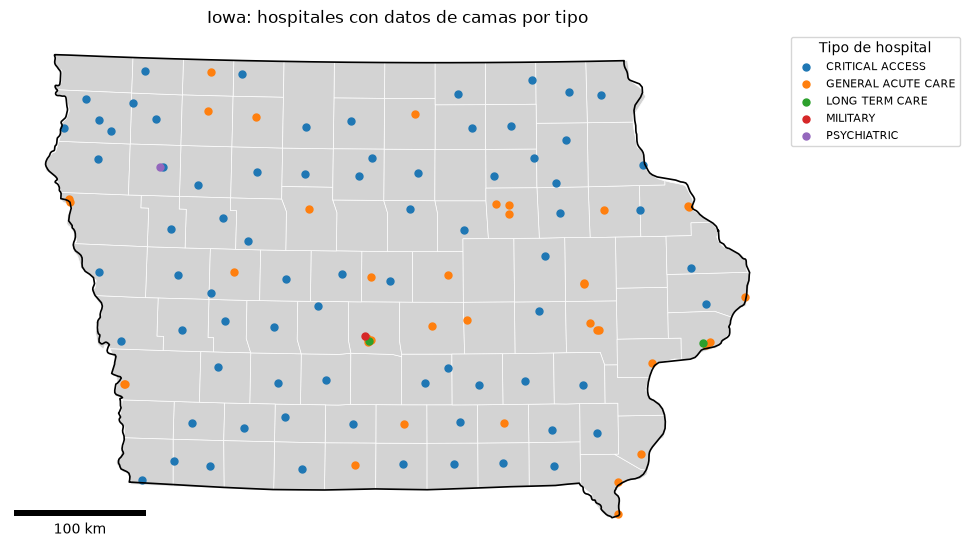

In [6]:
def mapa_base(ax):
    """Dibuja condados (gris claro) y límite estatal de Iowa en ``ax``."""
    cond_ia.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.5)
    estado_ia.boundary.plot(ax=ax, color="black", linewidth=1.2)
    ax.add_artist(ScaleBar(1, units="m", location="lower left"))
    ax.set_axis_off()


fig, ax = plt.subplots(figsize=(10, 7))
mapa_base(ax)
hosp_ia.plot(ax=ax, column="tipo", categorical=True, cmap="tab10",
             markersize=25, legend=True,
             legend_kwds={"title": "Tipo de hospital", "loc": "upper left", "bbox_to_anchor": (1, 1), "fontsize": 8})
ax.set_title("Iowa: hospitales con datos de camas por tipo")
plt.show()

**RESULTADOS**

Se observa una red muy dispersa, casi cada condado tiene un hospital **Critical Access** (≤ 25 camas), mientras que los hospitales **General Acute Care** se concentran en las ciudades (según la columna `ciudad`: Des Moines, Council Bluffs, Sioux City, Waterloo, Cedar Rapids, Iowa City y Dubuque).

### Task 1.2. Estadísticas por condado

Cada hospital se asigna a su condado con una **unión espacial** (`gpd.sjoin`, predicado `within`). Luego se suman hospitales, camas y camas UCI por condado, y se calculan las tasas por cada 10,000 habitantes. Los condados sin hospital reciben cero.

In [7]:
# Asignar cada hospital a su condado (unión espacial)
hosp_cond = gpd.sjoin(hosp_ia, cond_ia[["fips", "geometry"]], how="left", predicate="within")
agg = hosp_cond.groupby("fips").agg(
    hospitales=("nombre", "count"),
    camas_total=("camas_total", "sum"),
    camas_uci=("camas_icu", "sum"),
)
stats = cond_ia[["fips", "nombre", "poblacion", "geometry"]].merge(agg, on="fips", how="left")
stats[["hospitales", "camas_total", "camas_uci"]] = stats[["hospitales", "camas_total", "camas_uci"]].fillna(0)
stats["camas_10k"] = stats["camas_total"] / stats["poblacion"] * 10_000
stats["uci_10k"] = stats["camas_uci"] / stats["poblacion"] * 10_000

COLS = ["nombre", "hospitales", "camas_total", "camas_uci", "poblacion", "camas_10k", "uci_10k"]
print(f"Condados sin hospital: {(stats['hospitales'] == 0).sum()} de {len(stats)}")
print(f"Hospitales sin dato de camas UCI (se suman como 0): {hosp_ia['camas_icu'].isna().sum()} de {len(hosp_ia)}")
stats[COLS].sort_values("nombre").reset_index(drop=True)

Condados sin hospital: 12 de 99
Hospitales sin dato de camas UCI (se suman como 0): 74 de 117


,nombre,hospitales,camas_total,camas_uci,poblacion,camas_10k,uci_10k
0,Adair,1.00,25.00,0.00,"7,152.00",34.96,0.00
1,Adams,1.00,22.00,0.00,"3,602.00",61.08,0.00
2,Allamakee,1.00,25.00,0.00,"13,687.00",18.27,0.00
3,Appanoose,1.00,25.00,3.00,"12,426.00",20.12,2.41
4,Audubon,1.00,25.00,0.00,"5,496.00",45.49,0.00
...,...,...,...,...,...,...,...
94,Winnebago,0.00,0.00,0.00,"10,354.00",0.00,0.00
95,Winneshiek,1.00,25.00,0.00,"19,991.00",12.51,0.00
96,Woodbury,2.00,316.00,34.00,"103,107.00",30.65,3.30
97,Worth,0.00,0.00,0.00,"7,381.00",0.00,0.00


#### a) Cinco condados con menos camas por habitante (población > 10,000)

In [8]:
mayores = stats[stats["poblacion"] > 10_000]
print(f"Condados con más de 10,000 hab. y sin camas: {(mayores['camas_total'] == 0).sum()}")
# Empates en camas_10k se ordenan por población (mayor población primero)
mayores.sort_values(["camas_10k", "poblacion"], ascending=[True, False]).head(5)[COLS]

Condados con más de 10,000 hab. y sin camas: 10


,nombre,hospitales,camas_total,camas_uci,poblacion,camas_10k,uci_10k
23,Warren,0.00,0.00,0.00,"51,466.00",0.00,0.00
13,Jones,0.00,0.00,0.00,"20,681.00",0.00,0.00
3,Cedar,0.00,0.00,0.00,"18,627.00",0.00,0.00
46,Tama,0.00,0.00,0.00,"16,854.00",0.00,0.00
38,Mills,0.00,0.00,0.00,"15,109.00",0.00,0.00


**RESULTADOS**

- **10** condados con más de 10,000 habitantes no tienen ninguna cama hospitalaria, por lo que hay empate en 0. Se muestran los cinco más poblados: **Warren, Jones, Cedar, Tama y Mills**.
- Warren (51,466 hab.) es el caso más crítico por población, depende por completo de hospitales de otros condados (está junto a Des Moines).

#### b) Cinco condados con mayor concentración de camas

In [9]:
mas_camas = stats.nlargest(5, "camas_10k")[COLS]
mas_camas

,nombre,hospitales,camas_total,camas_uci,poblacion,camas_10k,uci_10k
34,Johnson,3.00,962.00,95.00,"151,140.00",63.65,6.29
76,Adams,1.00,22.00,0.00,"3,602.00",61.08,0.00
79,Cherokee,2.00,61.00,0.00,"11,235.00",54.29,0.00
59,Cerro Gordo,1.00,205.00,18.00,"42,450.00",48.29,4.24
0,Audubon,1.00,25.00,0.00,"5,496.00",45.49,0.00


In [10]:
# Hospitales de los 5 condados con más camas por habitante
hosp_cond[hosp_cond["fips"].isin(stats.nlargest(5, "camas_10k")["fips"])][
    ["condado", "nombre", "tipo", "camas_total"]
].sort_values("camas_total", ascending=False)

,condado,nombre,tipo,camas_total
6786,JOHNSON,UNIVERSITY OF IOWA HOSPITAL & CLINICS,GENERAL ACUTE CARE,716.00
6673,JOHNSON,MERCY HOSPITAL,GENERAL ACUTE CARE,218.00
6969,CERRO GORDO,MERCY MEDICAL CENTER-NORTH IOWA,GENERAL ACUTE CARE,205.00
3714,CHEROKEE,CHEROKEE MENTAL HEALTH INSTITUTE,PSYCHIATRIC,36.00
2186,JOHNSON,IOWA MEDICAL AND CLASSIFICATION CENTER,GENERAL ACUTE CARE,28.00
6514,AUDUBON,AUDUBON COUNTY MEMORIAL HOSPITAL,CRITICAL ACCESS,25.00
6849,CHEROKEE,CHEROKEE REGIONAL MEDICAL CENTER,CRITICAL ACCESS,25.00
816,ADAMS,CHI HEALTH - MERCY CORNING,CRITICAL ACCESS,22.00


**RESULTADOS**: _¿La concentración representa una ventaja de acceso para la población del condado?_

La alta concentración **no siempre** significa mejor acceso para la población del condado:

- **Johnson (63.65 camas/10k):** contiene el *University of Iowa Hospital & Clinics* (716 camas), hospital universitario de referencia para todo el estado. Sus camas atienden pacientes de muchos condados.
- **Cerro Gordo (48.29):** el *Mercy Medical Center–North Iowa* (205 camas) es un hospital regional del norte del estado.
- **Cherokee (54.29):** una parte de sus camas es del *Cherokee Mental Health Institute*, hospital psiquiátrico estatal, que no da atención general.
- **Adams (61.08) y Audubon (45.49):** solo tienen un hospital de 22–25 camas, pero su población es muy pequeña (3,602 y 5,496 hab.). La tasa alta es un **efecto del denominador pequeño**, no de mayor capacidad.

Por tanto, las tasas por condado reflejan sobre todo la presencia de **hospitales regionales** o de **poblaciones pequeñas**, no el acceso real.

#### c) Distribuciones de camas

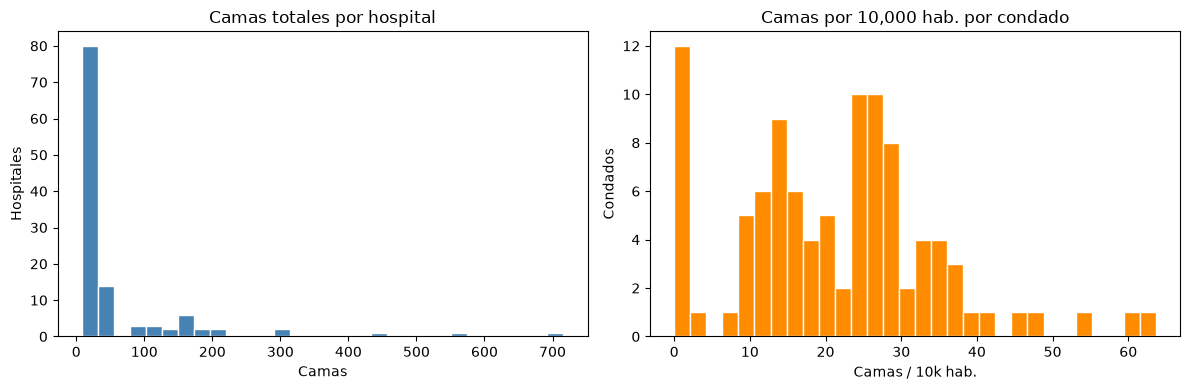

,media,mediana,máximo,asimetría
camas por hospital,63.89,25.00,716.00,4.04
camas/10k por condado,21.19,21.83,63.65,0.53


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(hosp_ia["camas_total"], bins=30, color="steelblue", edgecolor="white")
axes[0].set(title="Camas totales por hospital", xlabel="Camas", ylabel="Hospitales")
axes[1].hist(stats["camas_10k"], bins=30, color="darkorange", edgecolor="white")
axes[1].set(title="Camas por 10,000 hab. por condado", xlabel="Camas / 10k hab.", ylabel="Condados")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "media": [hosp_ia["camas_total"].mean(), stats["camas_10k"].mean()],
    "mediana": [hosp_ia["camas_total"].median(), stats["camas_10k"].median()],
    "máximo": [hosp_ia["camas_total"].max(), stats["camas_10k"].max()],
    "asimetría": [hosp_ia["camas_total"].skew(), stats["camas_10k"].skew()],
}, index=["camas por hospital", "camas/10k por condado"])

**RESULTADOS**

_Forma de cada distribución_:

- **Camas por hospital:** muy **asimétrica a la derecha** (asimetría 4.04). La mediana es 25 camas (límite de los Critical Access) y la media 63.9; unos pocos hospitales grandes son **valores extremos** (máx. 716).
- **Camas por 10,000 hab. por condado:** asimetría moderada (0.53); media (21.19) y mediana (21.83) parecidas. Destaca un **pico en cero** (12 condados sin hospital) y algunos valores altos (> 45) en condados pequeños o con hospitales regionales.

_¿Qué implica eso para el análisis de cobertura?_

Implica que contar hospitales no equivale a medir capacidad, porque la mayoría son pequeños. Además, los ceros y los extremos afectan los promedios, por lo que el análisis de cobertura debe complementarse con la distancia y no solo con tasas por condado.

### Task 1.3. Análisis de buffer de cobertura

Se definen tres funciones reutilizables:

- `cobertura_unificada`: crea buffers de radio *r* alrededor de cada hospital y los une (`union_all`, equivalente a `unary_union`).
- `fraccion_cubierta`: calcula qué fracción del área de cada condado queda dentro de la cobertura.
- `cobertura_poblacional`: multiplica esa fracción por la población del condado (supuesto de **población uniforme**).

In [12]:
def cobertura_unificada(puntos, radio_km):
    """Devuelve la unión (``unary_union``) de buffers de ``radio_km`` alrededor de ``puntos``."""
    return puntos.buffer(radio_km * 1000).union_all()


def fraccion_cubierta(condados, area_cubierta):
    """Devuelve, por condado, la fracción de su área dentro de ``area_cubierta``."""
    return condados.intersection(area_cubierta).area / condados.area


def cobertura_poblacional(condados, area_cubierta):
    """Estima la población cubierta asumiendo población uniforme dentro de cada condado."""
    return (fraccion_cubierta(condados, area_cubierta) * condados["poblacion"]).sum()


def clasificar_cobertura(fraccion, tol=0.999):
    """Clasifica cada fracción cubierta como "Completo", "Parcial" o "No cubierto"."""
    return pd.Series(np.select([fraccion >= tol, fraccion > 0], ["Completo", "Parcial"], "No cubierto"),
                     index=fraccion.index)

#### a-b). Buffers de 10, 25 y 50 km y población cubierta

In [13]:
POB_TOTAL = cond_ia["poblacion"].sum()
coberturas = {r: cobertura_unificada(hosp_ia, r) for r in (10, 25, 50)}

tabla_cob = pd.DataFrame([
    {"radio_km": r,
     "poblacion_cubierta": cobertura_poblacional(cond_ia, area),
     "poblacion_total": POB_TOTAL}
    for r, area in coberturas.items()
])
tabla_cob["cobertura_%"] = tabla_cob["poblacion_cubierta"] / POB_TOTAL * 100
tabla_cob

,radio_km,poblacion_cubierta,poblacion_total,cobertura_%
0,10,"757,646.22","3,155,070.00",24.01
1,25,"2,808,121.48","3,155,070.00",89.00
2,50,"3,155,065.92","3,155,070.00",100.00


**RESULTADOS**

- **10 km:** 24.01% de la población.
- **25 km:** 89.00%.
- **50 km:** prácticamente el 100%.

El salto entre 10 y 25 km muestra que la mayoría de los habitantes vive a una distancia intermedia de un hospital.

#### c) Mapa de cobertura a 25 km

Cada condado se clasifica como **completo** (≥ 99.9% de su área cubierta), **parcial** o **no cubierto**. Se usa la paleta divergente RdYlBu (rojo = sin cobertura, azul = completo). Las zonas sin cobertura dentro de los condados se sombrean en rojo.

cobertura_25
Parcial     83
Completo    16
Name: count, dtype: int64


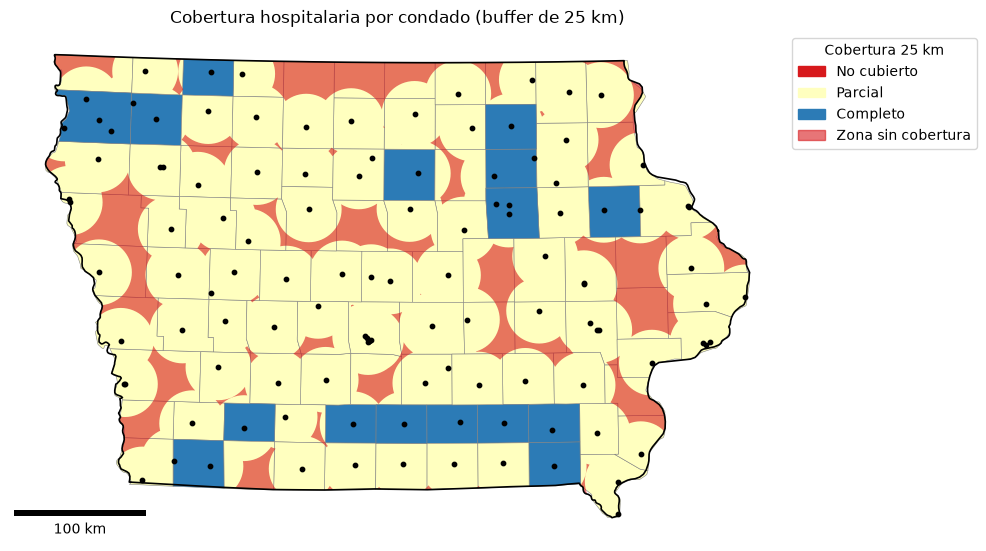

In [14]:
cob25 = coberturas[25]
frac25 = fraccion_cubierta(cond_ia, cob25)
cond_ia["cobertura_25"] = clasificar_cobertura(frac25)
print(cond_ia["cobertura_25"].value_counts())

colores = {"No cubierto": "#d7191c", "Parcial": "#ffffbf", "Completo": "#2c7bb6"}  # divergente RdYlBu
fig, ax = plt.subplots(figsize=(10, 7))
cond_ia.plot(ax=ax, color=cond_ia["cobertura_25"].map(colores), edgecolor="grey", linewidth=0.4)
estado_ia.difference(cob25).plot(ax=ax, color="#d7191c", alpha=0.6)  # zonas sin cobertura
estado_ia.boundary.plot(ax=ax, color="black", linewidth=1.2)
hosp_ia.plot(ax=ax, color="black", markersize=10)
ax.legend(handles=[Patch(color=c, label=l) for l, c in colores.items()]
          + [Patch(color="#d7191c", alpha=0.6, label="Zona sin cobertura")],
          title="Cobertura 25 km", loc="upper left", bbox_to_anchor=(1, 1))
ax.add_artist(ScaleBar(1, units="m", location="lower left"))
ax.set_title("Cobertura hospitalaria por condado (buffer de 25 km)")
ax.set_axis_off()
plt.show()

**RESULTADOS**

- **Ningún condado** queda totalmente sin cobertura; **16** están completos y **83** parciales.
- Las zonas sin cobertura (rojo) son **franjas entre hospitales**, más extensas en el **borde norte**, el **oeste** (junto al río Missouri) y el **centro-este**.
- Los condados completos se ubican en el noroeste, el norte-centro y el sur, donde hay varios hospitales cercanos entre sí.

## Task 2 — Sensibilidad, índice de vulnerabilidad y MCLP

### Task 2.1. Distancia al hospital más cercano

#### a) Distancia desde el centroide de cada condado

Se usa `gpd.sjoin_nearest` con `distance_col`, que busca el hospital más cercano y devuelve la distancia en metros.

In [15]:
centroides = cond_ia[["fips", "nombre", "poblacion"]].copy()
centroides = gpd.GeoDataFrame(centroides, geometry=cond_ia.centroid, crs=CRS_PROY)
cercano = gpd.sjoin_nearest(
    centroides, hosp_ia[["nombre", "tipo", "camas_total", "geometry"]],
    how="left", distance_col="dist_m", lsuffix="cond", rsuffix="hosp",
).drop_duplicates("fips")
cercano["dist_km"] = cercano["dist_m"] / 1000
cond_ia["dist_km"] = cond_ia["fips"].map(cercano.set_index("fips")["dist_km"])

top10_dist = cercano.nlargest(10, "dist_km")
top10_dist[["nombre_cond", "poblacion", "dist_km"]].reset_index(drop=True)

,nombre_cond,poblacion,dist_km
0,Jones,"20,681.00",38.28
1,Hamilton,"14,773.00",37.56
2,Cedar,"18,627.00",35.04
3,Mills,"15,109.00",31.92
4,Winnebago,"10,354.00",31.61
5,Woodbury,"103,107.00",31.58
6,Tama,"16,854.00",31.15
7,Louisa,"11,035.00",29.50
8,Warren,"51,466.00",29.00
9,Taylor,"6,121.00",28.33


**RESULTADOS**

- Los condados más alejados están a **28–38 km** de su hospital más cercano (Jones, Hamilton y Cedar encabezan la lista).
- **Woodbury** aparece con 31.58 km aunque tiene 2 hospitales, ambos están en Sioux City, en el borde oeste del condado, lejos del centroide. Esto es una limitación de usar el **centroide** como referencia.

#### b) Curva de cobertura acumulada (5–100 km)

Se reutiliza `cobertura_poblacional` para cada radio. El **punto de inflexión** se toma como el punto de la curva más alejado de la recta que une sus extremos (método del codo).

In [16]:
radios = np.arange(5, 105, 5)
curva = pd.DataFrame({
    "radio_km": radios,
    "cobertura_%": [cobertura_poblacional(cond_ia, cobertura_unificada(hosp_ia, r)) / POB_TOTAL * 100
                    for r in radios],
})
curva["ganancia_pp"] = curva["cobertura_%"].diff()
curva

,radio_km,cobertura_%,ganancia_pp
0,5,7.10,NaN
1,10,24.01,16.92
2,15,47.57,23.56
3,20,71.78,24.21
4,25,89.00,17.22
5,30,96.48,7.48
6,35,98.94,2.46
7,40,99.80,0.86
8,45,99.97,0.17
9,50,100.00,0.03


Punto de inflexión: 30 km (96.48 % de cobertura)


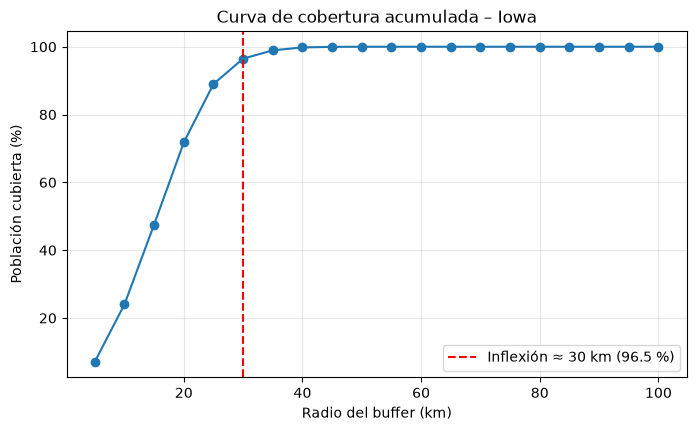

In [17]:
# Punto de inflexión (codo): punto de la curva más alejado de la recta que une sus extremos
x, y = curva["radio_km"], curva["cobertura_%"]
recta = y.iloc[0] + (x - x.iloc[0]) * (y.iloc[-1] - y.iloc[0]) / (x.iloc[-1] - x.iloc[0])
inflexion = curva.loc[(y - recta).idxmax()]
print(f"Punto de inflexión: {inflexion['radio_km']:.0f} km ({inflexion['cobertura_%']:.2f} % de cobertura)")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(curva["radio_km"], curva["cobertura_%"], marker="o")
ax.axvline(inflexion["radio_km"], color="red", linestyle="--",
           label=f"Inflexión ≈ {inflexion['radio_km']:.0f} km ({inflexion['cobertura_%']:.1f} %)")
ax.set(xlabel="Radio del buffer (km)", ylabel="Población cubierta (%)",
       title="Curva de cobertura acumulada – Iowa")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

**RESULTADOS**

- La cobertura crece rápido entre 5 y 25 km (ganancias de 17–24 puntos porcentuales cada 5 km).
- El **punto de inflexión está en 30 km (96.48%)**: a partir de ahí la ganancia cae a 2.46 p.p. (35 km) y luego a menos de 1 p.p.

_¿Qué significa el punto de inflexión para la política de acceso hospitalario en Iowa?_

En Iowa casi toda la población vive a ≤ 30 km en línea recta de un hospital. Ampliar el radio aceptable más allá de 30 km apenas agrega población; la brecha restante (≈ 3.5%) está **dispersa en zonas rurales** y requiere intervenciones focalizadas (servicios móviles, telemedicina, transporte de emergencia), no nuevos hospitales grandes.

#### c) Tipo de hospital más cercano a los cinco condados más alejados

In [18]:
top10_dist.head(5)[["nombre_cond", "dist_km", "nombre_hosp", "tipo", "camas_total"]].reset_index(drop=True)

,nombre_cond,dist_km,nombre_hosp,tipo,camas_total
0,Jones,38.28,JACKSON COUNTY PUBLIC HOSPITAL,CRITICAL ACCESS,25.00
1,Hamilton,37.56,IOWA SPECIALTY HOSPITAL-CLARION,CRITICAL ACCESS,25.00
2,Cedar,35.04,MERCY HOSPITAL,GENERAL ACUTE CARE,218.00
3,Mills,31.92,METHODIST JENNIE EDMUNDSON,GENERAL ACUTE CARE,110.00
4,Winnebago,31.61,HANCOCK COUNTY HEALTH SYSTEM,CRITICAL ACCESS,25.00


In [19]:
print(f"Mediana de camas, hospitales más cercanos a los 5 condados más alejados: "
      f"{top10_dist.head(5)['camas_total'].median():.0f}")
print(f"Mediana de camas, todos los hospitales de Iowa: {hosp_ia['camas_total'].median():.0f}")

Mediana de camas, hospitales más cercanos a los 5 condados más alejados: 25
Mediana de camas, todos los hospitales de Iowa: 25


**RESULTADOS**

- 3 de los 5 condados (Jones, Hamilton y Winnebago) tienen como hospital más cercano un **Critical Access** de 25 camas.
- Cedar y Mills quedan cerca de hospitales **General Acute Care** de mayor tamaño (218 y 110 camas), porque están junto a áreas urbanas (Iowa City y Council Bluffs/Omaha).
- La mediana de camas del hospital más cercano (25) es igual a la mediana estatal (25).

_¿Los condados más alejados tienden a estar cerca de hospitales de menor capacidad?_

Existe una tendencia leve, los condados más alejados dependen con más frecuencia de hospitales pequeños, pero no es una regla, ya que algunos están cerca de hospitales grandes de ciudades vecinas.

### Task 2.2. Índice de vulnerabilidad de acceso hospitalario (IVAH)

Se combinan tres componentes por condado:

1. **Distancia** del centroide al hospital más cercano.
2. **Inverso de camas por 10,000 hab.** (condados sin hospital → valor máximo).
3. **Ocupación promedio** de los hospitales a ≤ 50 km del centroide (sin hospitales → valor máximo).

#### a) Componentes y normalización min-max

In [20]:
def min_max(s):
    """Normaliza una serie al rango [0, 1] con la transformación min-max."""
    return (s - s.min()) / (s.max() - s.min())


# Componente 1: distancia al hospital más cercano
c1 = cond_ia["dist_km"]

# Componente 2: inverso de camas por habitante (sin hospitales -> máximo)
inv_camas = 1 / stats.set_index("fips")["camas_10k"].replace(0, np.nan)
c2 = cond_ia["fips"].map(inv_camas.fillna(inv_camas.max()))

# Componente 3: ocupación promedio de hospitales a <= 50 km del centroide (sin hospitales -> máximo)
cerca50 = gpd.sjoin(centroides, hosp_ia[["ocupacion_total", "geometry"]].assign(
    geometry=hosp_ia.buffer(50_000)), how="left", predicate="within")
ocup = cerca50.groupby("fips")["ocupacion_total"].mean()
c3 = cond_ia["fips"].map(ocup.fillna(ocup.max()))

indice = cond_ia[["fips", "nombre", "poblacion", "geometry"]].copy()
indice["c1_dist"] = min_max(c1).values
indice["c2_camas"] = min_max(c2).values
indice["c3_ocup"] = min_max(c3).values
print(f"Condados sin hospital a <= 50 km: {ocup.isna().sum()}")
indice[["c1_dist", "c2_camas", "c3_ocup"]].describe()

Condados sin hospital a <= 50 km: 0


,c1_dist,c2_camas,c3_ocup
count,99.00,99.00,99.00
mean,0.27,0.22,0.49
std,0.25,0.31,0.22
min,0.00,0.00,0.00
25%,0.08,0.05,0.33
50%,0.19,0.08,0.45
75%,0.35,0.18,0.64
max,1.00,1.00,1.00


**RESULTADOS**

Todos los condados tienen al menos un hospital a ≤ 50 km, por lo que la regla de "valor máximo" del componente 3 no se aplica.

_Justificación de min-max_: $x' = \dfrac{x - x_{\min}}{x_{\max} - x_{\min}}$

- Los componentes tienen **unidades distintas** (km, inverso de camas, proporción); min-max los lleva a una escala común [0, 1] sin cambiar su orden.
- Es fácil de interpretar: 0 = condado menos vulnerable del estado y 1 = el más vulnerable en ese componente.
- Conserva las distancias relativas entre condados, lo que permite promediarlos con pesos.

_¿Cuándo no es apropiada?_

- Con **valores extremos**, el resto se comprime cerca de 0. Ocurre en el componente 2, la mediana es 0.08 porque el máximo lo fijan los condados sin camas.
- Depende del mínimo y máximo de **esta muestra**. No permite comparar con otros estados u otros años. En esos casos conviene usar z-scores, rangos o umbrales fijos.

#### b) Índice compuesto con pesos

| Componente | Peso | Justificación |
|---|---|---|
| Distancia | **0.40** | En emergencias (infarto, trauma, parto) el tiempo de llegada determina el resultado; es la barrera más difícil de corregir en un estado rural. |
| Camas per cápita | **0.35** | Mide la capacidad instalada: aunque el hospital esté cerca, sin camas suficientes no hay atención. Es un dato estable (estructural). |
| Ocupación | **0.25** | Indica saturación, pero es un dato de un solo momento, falta en algunos hospitales y se promedia en 50 km, por lo que se le da menor peso. |

In [21]:
PESOS = {"c1_dist": 0.40, "c2_camas": 0.35, "c3_ocup": 0.25}


def calcular_indice(df, pesos):
    """Devuelve el promedio ponderado de los componentes según ``pesos`` (deben sumar 1)."""
    return sum(df[col] * w for col, w in pesos.items())


indice["ivah"] = calcular_indice(indice, PESOS)
indice["categoria"] = pd.qcut(indice["ivah"], 5, labels=["Muy baja", "Baja", "Media", "Alta", "Muy alta"])
top10_vuln = indice.nlargest(10, "ivah")
top10_vuln[["nombre", "poblacion", "c1_dist", "c2_camas", "c3_ocup", "ivah"]].reset_index(drop=True)

,nombre,poblacion,c1_dist,c2_camas,c3_ocup,ivah
0,Hamilton,"14,773.00",0.98,1.00,0.89,0.97
1,Cedar,"18,627.00",0.91,1.00,0.87,0.93
2,Jones,"20,681.00",1.00,1.00,0.56,0.89
3,Warren,"51,466.00",0.76,1.00,0.94,0.89
4,Winnebago,"10,354.00",0.82,1.00,0.80,0.88
5,Mills,"15,109.00",0.83,1.00,0.60,0.83
6,Worth,"7,381.00",0.66,1.00,0.68,0.79
7,Louisa,"11,035.00",0.77,1.00,0.49,0.78
8,Tama,"16,854.00",0.81,1.00,0.41,0.78
9,Dallas,"93,453.00",0.44,1.00,0.86,0.74


**RESULTADOS**

- Los condados más vulnerables son **Hamilton, Cedar, Jones, Warren y Winnebago**, combinan distancias altas, ausencia de camas y hospitales cercanos con alta ocupación.
- **Dallas** entra al top-10 con 0.74; aunque tiene un hospital, este único hospital (25 camas) atiende a 93,453 habitantes, por lo que su componente de camas es 1.00.

#### c) Mapa coroplético por quintiles

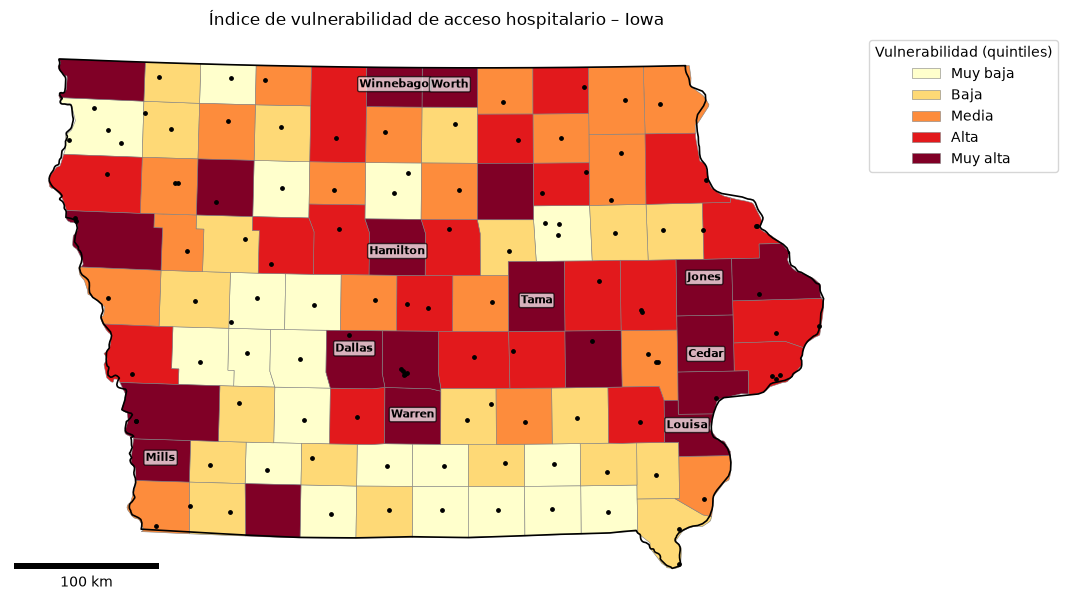

In [22]:
fig, ax = plt.subplots(figsize=(11, 7.5))
indice.plot(ax=ax, column="categoria", cmap="YlOrRd", categorical=True, legend=True,
            edgecolor="grey", linewidth=0.4,
            legend_kwds={"title": "Vulnerabilidad (quintiles)", "loc": "upper left", "bbox_to_anchor": (1, 1)})
estado_ia.boundary.plot(ax=ax, color="black", linewidth=1.2)
hosp_ia.plot(ax=ax, color="black", markersize=6)
for _, fila in top10_vuln.iterrows():
    p = fila.geometry.representative_point()
    ax.annotate(fila["nombre"], (p.x, p.y), ha="center", fontsize=8, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.7))
ax.add_artist(ScaleBar(1, units="m", location="lower left"))
ax.set_title("Índice de vulnerabilidad de acceso hospitalario – Iowa")
ax.set_axis_off()
plt.show()

**RESULTADOS**

- Las categorías **muy alta** se ubican en dos tipos de zonas: (a) condados **rurales sin hospital** (Hamilton, Winnebago, Worth, Tama, Louisa) y (b) condados **sin hospital o con poca capacidad junto a condados urbanos** (Warren, Dallas, Jones, Cedar, Mills).
- En el caso (b), la población probablemente usa hospitales del condado vecino; el índice los marca como vulnerables porque mide la oferta **dentro** del condado.
- **Polk** (6 hospitales, a 9 km) aparece en "muy alta" solo por la ocupación (componente 3 = 1.00). Su IVAH es 0.36 (lugar 18 de 99). Al usar quintiles, el quintil superior incluye 20 condados con índices muy diferentes.

### Task 2.3. Ubicación de nuevos hospitales (MCLP simplificado)

El problema MCLP busca ubicar *p* nuevos hospitales para cubrir la mayor población posible. Se resuelve con un **algoritmo voraz** (greedy).

#### a) Grilla de candidatos (50 km)

Se crea una grilla regular con `np.meshgrid` sobre la extensión del estado y se conservan solo los puntos que intersecan el límite estatal (`gpd.sjoin`, predicado `intersects`).

In [23]:
PASO = 50_000  # 50 km
xmin, ymin, xmax, ymax = estado_ia.total_bounds
xs, ys = np.meshgrid(np.arange(xmin, xmax, PASO), np.arange(ymin, ymax, PASO))
grilla = gpd.GeoDataFrame(geometry=gpd.points_from_xy(xs.ravel(), ys.ravel()), crs=CRS_PROY)
candidatos = gpd.sjoin(grilla, estado_ia[["geometry"]], predicate="intersects").drop(columns="index_right")
candidatos = candidatos.reset_index(drop=True)
print(f"Puntos de la grilla: {len(grilla)} | dentro de Iowa: {len(candidatos)}")

Puntos de la grilla: 88 | dentro de Iowa: 53


#### b) Población adicional por candidato (25 km)

Para cada punto se calcula el área de su buffer que **no** está cubierta actualmente y se multiplica por la densidad de población de cada condado.

In [24]:
RADIO_NUEVO = 25


def poblacion_adicional(punto, area_cubierta):
    """Estima la población sin cobertura que cubriría un buffer de ``RADIO_NUEVO`` km en ``punto``."""
    nuevo = punto.buffer(RADIO_NUEVO * 1000).difference(area_cubierta)
    densidad = cond_ia["poblacion"] / cond_ia.area
    return (cond_ia.intersection(nuevo).area * densidad).sum()


candidatos["pob_adicional"] = [poblacion_adicional(p, cob25) for p in candidatos.geometry]
candidatos.nlargest(5, "pob_adicional")

,geometry,pob_adicional
34,POINT (652265.781 4671047.002),"32,193.73"
26,POINT (252265.781 4671047.002),"26,908.99"
8,POINT (302265.781 4571047.002),"25,968.14"
36,POINT (252265.781 4721047.002),"25,382.70"
33,POINT (602265.781 4671047.002),"23,785.01"


**RESULTADO**

El mejor candidato aislado agrega ≈ 32,194 habitantes. Los valores son bajos porque la cobertura actual a 25 km ya es del 89%.

#### c) Algoritmo voraz (3 hospitales)

En cada iteración: (1) se calcula la ganancia de cada candidato con la cobertura actual, (2) se elige el de mayor ganancia, (3) se agrega su buffer a la cobertura y (4) se repite.

In [25]:
cobertura_actual = cob25
seleccion = []
for i in range(3):
    ganancias = [poblacion_adicional(p, cobertura_actual) for p in candidatos.geometry]
    mejor = int(np.argmax(ganancias))
    punto = candidatos.geometry[mejor]
    cobertura_actual = cobertura_actual.union(punto.buffer(RADIO_NUEVO * 1000))
    seleccion.append({"iteracion": i + 1, "geometry": punto, "pob_adicional": ganancias[mejor],
                      "cobertura_%": cobertura_poblacional(cond_ia, cobertura_actual) / POB_TOTAL * 100})

seleccion = gpd.GeoDataFrame(seleccion, crs=CRS_PROY)
seleccion["condado"] = gpd.sjoin(seleccion, cond_ia[["nombre", "geometry"]], predicate="within")["nombre"]
print(f"Cobertura inicial (25 km): {cobertura_poblacional(cond_ia, cob25) / POB_TOTAL * 100:.2f} %")
seleccion.drop(columns="geometry")

Cobertura inicial (25 km): 89.00 %


,iteracion,pob_adicional,cobertura_%,condado
0,1,"32,193.73",90.02,Jones
1,2,"26,908.99",90.88,Monona
2,3,"25,968.14",91.70,Pottawattamie


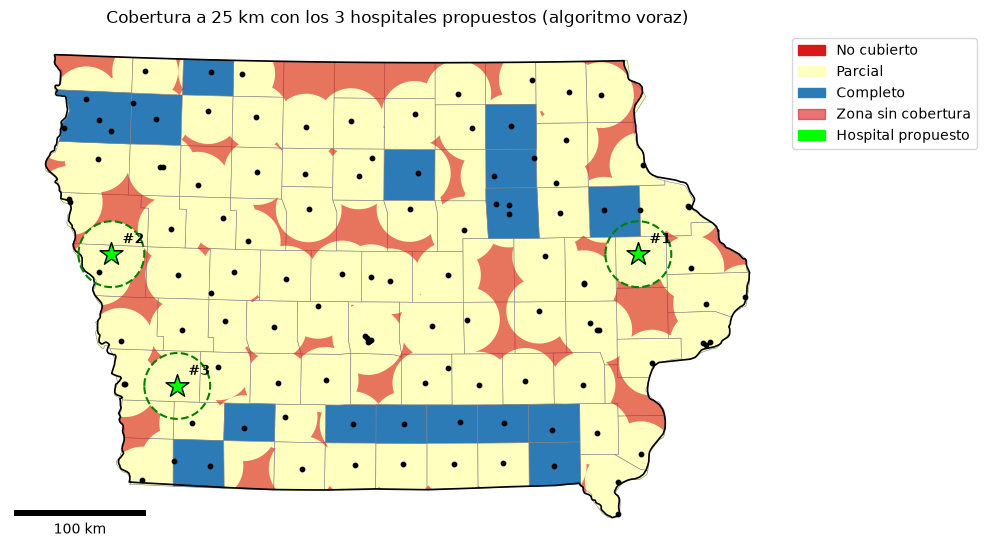

In [26]:
frac_final = fraccion_cubierta(cond_ia, cobertura_actual)
estado_final = clasificar_cobertura(frac_final)

fig, ax = plt.subplots(figsize=(10, 7))
cond_ia.plot(ax=ax, color=estado_final.map(colores), edgecolor="grey", linewidth=0.4)
estado_ia.difference(cobertura_actual).plot(ax=ax, color="#d7191c", alpha=0.6)
estado_ia.boundary.plot(ax=ax, color="black", linewidth=1.2)
hosp_ia.plot(ax=ax, color="black", markersize=10)
gpd.GeoSeries(seleccion.buffer(RADIO_NUEVO * 1000), crs=CRS_PROY).boundary.plot(ax=ax, color="green", linestyle="--")
seleccion.plot(ax=ax, color="lime", edgecolor="black", marker="*", markersize=300)
for _, f in seleccion.iterrows():
    ax.annotate(f"#{f['iteracion']}", (f.geometry.x, f.geometry.y), xytext=(8, 8),
                textcoords="offset points", fontweight="bold")
ax.legend(handles=[Patch(color=c, label=l) for l, c in colores.items()]
          + [Patch(color="#d7191c", alpha=0.6, label="Zona sin cobertura"),
             Patch(color="lime", label="Hospital propuesto")], loc="upper left", bbox_to_anchor=(1, 1))
ax.add_artist(ScaleBar(1, units="m", location="lower left"))
ax.set_title("Cobertura a 25 km con los 3 hospitales propuestos (algoritmo voraz)")
ax.set_axis_off()
plt.show()

**RESULTADOS**

| Iteración | Condado | Población adicional | Cobertura acumulada |
|---|---|---|---|
| Inicial | — | — | 89.00% |
| 1 | Jones | 32,194 | 90.02% |
| 2 | Monona | 26,909 | 90.88% |
| 3 | Pottawattamie | 25,968 | 91.70% |

- Los tres hospitales agregan ≈ **85,000 habitantes** (+2.7 p.p.).
- Se ubican en franjas sin cobertura del **centro-este** (Jones, 3.° en el IVAH) y del **oeste**, junto al río Missouri (Monona y Pottawattamie).
- La ganancia decrece en cada iteración.

## Task 3 — Red vial y reflexión metodológica

### Task 3.1. Buffer circular vs. isocrona de 30 minutos

#### a) Isocronas sobre la red vial real

- Se eligen los **3 condados con mayor IVAH que tienen hospital** (los primeros del ranking no tienen ninguno) y, en cada uno, el hospital con más camas.
- `add_edge_speeds` asigna velocidades por tipo de vía (`highway`) y `add_edge_travel_times` calcula el tiempo de cada tramo.
- Con Dijkstra se obtienen los nodos alcanzables en ≤ 30 min; la isocrona es la **envolvente convexa** de esos nodos.
- La población cubierta se estima igual que antes (fracción de área × población, solo condados de Iowa).

In [27]:
# Condados más vulnerables que tienen al menos un hospital; se toma el hospital con más camas
vuln_con_hosp = indice.merge(stats[["fips", "hospitales"]], on="fips")
vuln_con_hosp = vuln_con_hosp[vuln_con_hosp["hospitales"] > 0].nlargest(3, "ivah")
hosp_sel = (hosp_cond[hosp_cond["fips"].isin(vuln_con_hosp["fips"])]
            .sort_values("camas_total", ascending=False).drop_duplicates("fips"))
hosp_sel = hosp_sel.merge(vuln_con_hosp[["fips", "nombre", "ivah"]].rename(columns={"nombre": "condado_ivah"}), on="fips")
hosp_sel[["condado_ivah", "ivah", "nombre", "tipo", "camas_total"]]

,condado_ivah,ivah,nombre,tipo,camas_total
0,Woodbury,0.54,ST. LUKES'S REGIONAL MEDICAL CENTER,GENERAL ACUTE CARE,159.00
1,Pottawattamie,0.46,CHI HEALTH MERCY HOSPITAL,GENERAL ACUTE CARE,145.00
2,Dallas,0.74,DALLAS COUNTY HOSPITAL,CRITICAL ACCESS,25.00


In [28]:
PBF_URL = "https://download.geofabrik.de/north-america/us/iowa-latest.osm.pbf"
PBF = DATA + "iowa-latest.osm.pbf"
VIAS = ["motorway", "trunk", "primary", "secondary", "tertiary", "unclassified", "residential",
        "living_street", "motorway_link", "trunk_link", "primary_link", "secondary_link", "tertiary_link"]


def descargar_pbf(url, ruta):
    """Descarga el extracto OSM de ``url`` en ``ruta`` si el archivo no existe."""
    if not os.path.exists(ruta):
        urllib.request.urlretrieve(url, ruta)


def extraer_red(pbf, lat, lon, dist_m, salida):
    """Recorta la red vial vehicular de ``pbf`` en una caja de lado ``2 * dist_m`` centrada en (lat, lon).

    Conserva las vías con ``highway`` en ``VIAS`` (sin ``access=private/no``) que tienen al menos
    un nodo dentro de la caja, y escribe un archivo ``.osm`` con esas vías y sus nodos.
    Si ``salida`` ya existe, no se vuelve a generar.
    """
    if os.path.exists(salida):
        return salida
    dlat = dist_m / 111_320
    dlon = dist_m / (111_320 * np.cos(np.radians(lat)))
    dentro = lambda n: abs(n.lat - lat) <= dlat and abs(n.lon - lon) <= dlon
    vias = osmium.FileProcessor(pbf).with_locations().with_filter(
        osmium.filter.TagFilter(*[("highway", v) for v in VIAS]))
    with osmium.BackReferenceWriter(salida, ref_src=pbf, overwrite=True) as writer:
        for w in vias:
            if w.is_way() and w.tags.get("access") not in ("private", "no") and any(dentro(n) for n in w.nodes):
                writer.add_way(w)
    return salida


def isocrona(G, lat, lon, minutos=30):
    """Devuelve la envolvente convexa (en ``CRS_PROY``) de los nodos alcanzables desde (lat, lon) en ``minutos``.

    ``G`` debe tener el atributo ``travel_time`` en sus aristas (``ox.add_edge_travel_times``).
    """
    origen = ox.distance.nearest_nodes(G, lon, lat)
    tiempos = nx.single_source_dijkstra_path_length(G, origen, cutoff=minutos * 60, weight="travel_time")
    nodos = ox.graph_to_gdfs(G, edges=False).loc[list(tiempos)]
    return nodos.to_crs(CRS_PROY).union_all().convex_hull


def recortes_geofabrik(hospitales_wgs, dist_m=55_000):
    """Descarga el PBF de Geofabrik (si falta) y genera un recorte ``.osm`` por hospital.

    Devuelve un diccionario ``{fips: ruta_osm}``.
    """
    descargar_pbf(PBF_URL, PBF)
    os.makedirs(DATA + "osm", exist_ok=True)
    return {h["fips"]: extraer_red(PBF, h.geometry.y, h.geometry.x, dist_m, f"{DATA}osm/red_{h['fips']}.osm")
            for _, h in hospitales_wgs.iterrows()}


hosp_sel_wgs = hosp_sel.to_crs(4326)
usar_overpass = True  # se desactiva en el primer fallo de Overpass
archivos = {}

isocronas, redes = [], {}
for _, h in hosp_sel_wgs.iterrows():
    lat, lon = h.geometry.y, h.geometry.x
    G = None
    if usar_overpass:
        try:  # método estándar: API Overpass
            G = ox.graph_from_point((lat, lon), dist=55_000, network_type="drive")
            fuente = "Overpass"
        except (RequestException, ValueError) as e:
            print(f"Overpass no disponible ({type(e).__name__}); se usa el extracto de Geofabrik.")
            usar_overpass = False
            archivos = recortes_geofabrik(hosp_sel_wgs)
    if G is None:  # respaldo: extracto de Geofabrik
        G = ox.graph_from_xml(archivos[h["fips"]])
        fuente = "Geofabrik"
    for _, _, d in G.edges(data=True):  # orden fijo de tipos de vía en tramos fusionados (reproducibilidad)
        if isinstance(d.get("highway"), list):
            d["highway"] = sorted(d["highway"])
    G = ox.add_edge_speeds(G)        # velocidad por tipo de vía (km/h)
    G = ox.add_edge_travel_times(G)  # tiempo de viaje por arista (s)
    isocronas.append(isocrona(G, lat, lon))
    redes[h["nombre"]] = ox.graph_to_gdfs(G, nodes=False)[["highway", "length", "speed_kph", "geometry"]].to_crs(CRS_PROY)
    print(f"{h['nombre']} [{fuente}]: {len(G.nodes):,} nodos, {len(G.edges):,} aristas")
    del G

Overpass no disponible (ConnectionError); se usa el extracto de Geofabrik.


ST. LUKES'S REGIONAL MEDICAL CENTER [Geofabrik]: 10,552 nodos, 30,743 aristas


CHI HEALTH MERCY HOSPITAL [Geofabrik]: 10,952 nodos, 30,488 aristas


DALLAS COUNTY HOSPITAL [Geofabrik]: 38,788 nodos, 106,009 aristas


In [29]:
filas = []
for (_, h), iso in zip(hosp_sel.iterrows(), isocronas):
    buf = h.geometry.buffer(25_000)
    filas.append({
        "hospital": h["nombre"], "condado": h["condado_ivah"],
        "area_buffer_km2": buf.area / 1e6, "area_isocrona_km2": iso.area / 1e6,
        "pob_buffer": cobertura_poblacional(cond_ia, buf),
        "pob_isocrona": cobertura_poblacional(cond_ia, iso),
    })
comp = pd.DataFrame(filas)
comp["dif_pob"] = comp["pob_isocrona"] - comp["pob_buffer"]
comp["dif_%"] = comp["dif_pob"] / comp["pob_buffer"] * 100
comp

,hospital,condado,area_buffer_km2,area_isocrona_km2,pob_buffer,pob_isocrona,dif_pob,dif_%
0,ST. LUKES'S REGIONAL MEDICAL CENTER,Woodbury,"1,960.34","2,805.68","35,451.43","71,229.27","35,777.84",100.92
1,CHI HEALTH MERCY HOSPITAL,Pottawattamie,"1,960.34","3,148.45","42,126.65","74,915.38","32,788.73",77.83
2,DALLAS COUNTY HOSPITAL,Dallas,"1,960.34","3,731.82","76,549.68","208,328.64","131,778.96",172.15


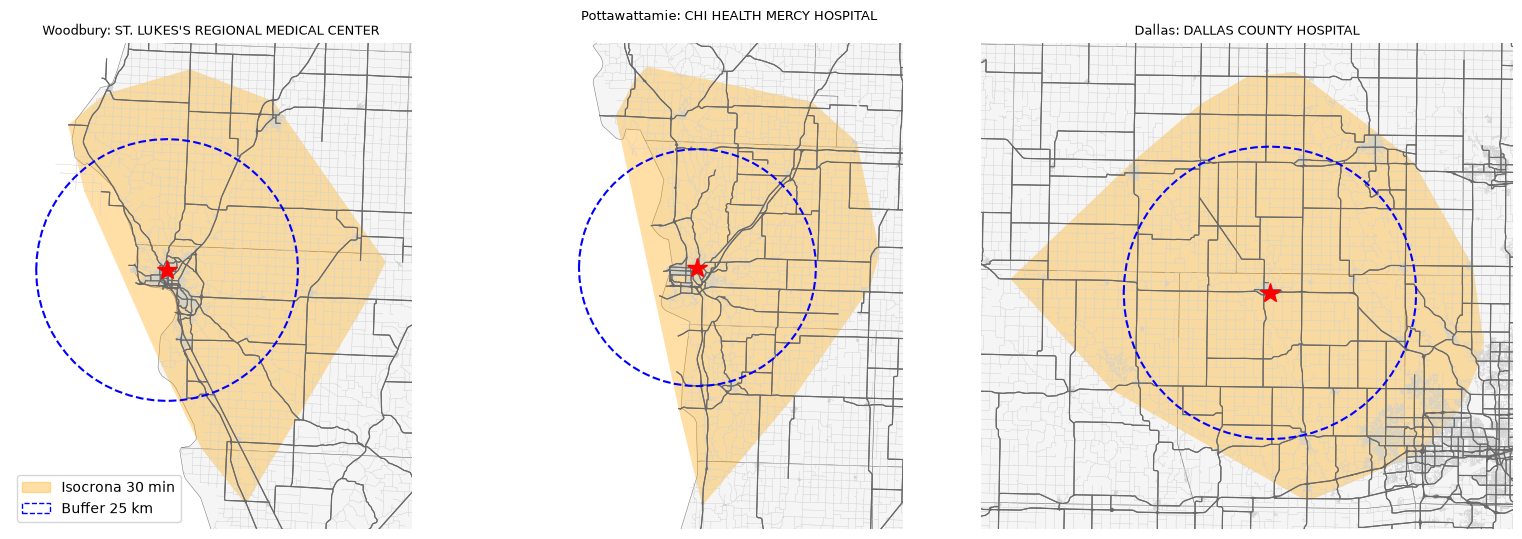

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, (_, h), iso in zip(axes, hosp_sel.iterrows(), isocronas):
    buf = h.geometry.buffer(25_000)
    aristas = redes[h["nombre"]]
    vias = aristas[aristas["highway"].astype(str).str.contains("motorway|trunk|primary|secondary")]
    cond_ia.plot(ax=ax, color="whitesmoke", edgecolor="grey", linewidth=0.4)
    aristas.plot(ax=ax, color="lightgrey", linewidth=0.2)
    vias.plot(ax=ax, color="dimgrey", linewidth=0.8)
    gpd.GeoSeries([iso], crs=CRS_PROY).plot(ax=ax, color="orange", alpha=0.35)
    gpd.GeoSeries([buf], crs=CRS_PROY).boundary.plot(ax=ax, color="blue", linestyle="--")
    ax.plot(h.geometry.x, h.geometry.y, "r*", markersize=15)
    xmin, ymin, xmax, ymax = iso.union(buf).bounds
    ax.set(xlim=(xmin - 5e3, xmax + 5e3), ylim=(ymin - 5e3, ymax + 5e3), title=f"{h['condado_ivah']}: {h['nombre']}")
    ax.title.set_fontsize(9)
    ax.set_axis_off()
axes[0].legend(handles=[Patch(color="orange", alpha=0.35, label="Isocrona 30 min"),
                        Patch(fill=False, edgecolor="blue", linestyle="--", label="Buffer 25 km")], loc="lower left")
plt.tight_layout()
plt.show()

In [31]:
# Velocidad media asignada por tipo de vía (todas las redes descargadas)
aristas = pd.concat(redes.values())
aristas["tipo_via"] = aristas["highway"].astype(str)
resumen = aristas.groupby("tipo_via").agg(km=("length", lambda s: s.sum() / 1000), vel_kph=("speed_kph", "mean"))
resumen.sort_values("km", ascending=False).head(8)

,km,vel_kph
tipo_via,,
residential,"45,016.86",44.64
tertiary,"10,885.21",57.31
secondary,"8,759.67",63.16
unclassified,"5,487.34",58.37
primary,"3,973.26",72.15
motorway,"1,382.33",106.30
trunk,732.33,88.50
"['residential', 'unclassified']",452.43,45.41


**RESULTADOS**

| Hospital (condado) | Pob. buffer 25 km | Pob. isocrona 30 min | Diferencia |
|---|---|---|---|
| St. Luke's (Woodbury) | 35,451 | 71,229 | +100.9% |
| CHI Health Mercy (Pottawattamie) | 42,127 | 74,915 | +77.8% |
| Dallas County Hospital (Dallas) | 76,550 | 208,329 | +172.2% |

- En los tres casos, la isocrona de 30 min cubre **más área y más población** que el buffer de 25 km (área: 2,806–3,732 km² vs. 1,960 km²).
- Las isocronas **no son circulares**: se alargan sobre las vías rápidas. Las autopistas (`motorway`) tienen 106 km/h asignados, frente a 45 km/h de las calles `residential`.
- En Woodbury y Pottawattamie, la isocrona se estira de norte a sur siguiendo la autopista paralela al río Missouri y se corta al oeste en el río (límite con Nebraska). En Dallas, se extiende hacia el este hasta el área urbana de Des Moines, lo que explica el mayor aumento de población.

*Notas:*

- La envolvente convexa incluye zonas entre carreteras que no son alcanzables, por lo que **agranda** la isocrona.
- Las velocidades son límites teóricos, sin semáforos ni tráfico.
- El extracto solo contiene vías de Iowa, por lo que no se consideran rutas por Nebraska o Dakota del Sur.

#### b) ¿Cuándo el buffer sobreestima o subestima la cobertura?

El buffer supone que se viaja en línea recta a una velocidad implícita de 25 km en 30 min (**50 km/h**). La diferencia con la realidad depende de la red vial:

**El buffer subestima la cobertura** cuando hay vías rápidas que salen del hospital:

- Sobre autopistas (106 km/h) y vías troncales (88 km/h), en 30 min se recorren 45–50 km, casi el doble del radio.
- Por eso las tres isocronas observadas son más grandes que el buffer y se alargan siguiendo esas vías (norte-sur junto al río Missouri; hacia Des Moines desde Dallas).

**El buffer sobreestima la cobertura** cuando la red es lenta, indirecta o tiene barreras:

- **Cuadrícula rural:** la mayor parte de la red de Iowa son caminos `residential`/`unclassified` (≈ 50,000 km de vías en las tres áreas, a ~45 km/h) que siguen una cuadrícula norte-sur/este-oeste. Para llegar a un punto en diagonal se recorre ≈ √2 veces la distancia en línea recta, y a 45 km/h en 30 min solo se avanzan ~22 km. Los puntos del buffer en diagonal y lejos de vías principales quedan **fuera** del alcance real.
- **Ríos:** el buffer de Woodbury y Pottawattamie cruza el río Missouri, que solo tiene pocos puentes. El área del otro lado se cuenta en el buffer aunque su acceso real sea mucho más largo.

*Conclusión*: en Iowa, el buffer de 25 km tiende a **subestimar** el acceso cerca de las autopistas y de las ciudades, y a **sobreestimarlo** en zonas rurales alejadas de las vías principales y del otro lado de los ríos.

#### c) Implicaciones para la política pública

1. **Ubicación de nuevos hospitales o servicios (Task 2.3).** Con isocronas, las zonas cercanas a autopistas pasan a estar cubiertas, mientras que las zonas rurales alejadas de las vías principales siguen sin cobertura. Los puntos propuestos por el algoritmo voraz cambiarían, los de Monona y Pottawattamie, junto a la autopista del río Missouri, podrían ya estar cubiertos en 30 min, y la prioridad pasaría al interior rural.

2. **Mantener o cerrar hospitales pequeños (Critical Access).** En EE.UU., la designación *Critical Access* depende de la distancia **por carretera** a otro hospital. Un análisis con buffers podría concluir que un hospital es "redundante" porque otro está a pocos km en línea recta, aunque por la red vial (cuadrícula o río de por medio) el viaje sea mucho más largo. Con isocronas, el cierre se evaluaría según el tiempo real que tardaría la población.

3. **Ubicación de bases de ambulancias y acuerdos de traslado.** Las isocronas muestran hacia dónde se llega rápido (corredores de autopista), lo que cambia qué zonas necesitan una base de ambulancias propia y hacia qué hospital conviene trasladar a los pacientes.

### Task 3.3. Reflexión metodológica

#### a) Sensibilidad del índice a los pesos

Se recalcula el IVAH con cinco configuraciones de pesos (distancia/camas/ocupación) y se compara el top-10 con la configuración base (coincidencias y correlación de Spearman de los rankings).

In [32]:
CONFIGS = {
    "Base (0.40/0.35/0.25)": PESOS,
    "Iguales (1/3)": {"c1_dist": 1 / 3, "c2_camas": 1 / 3, "c3_ocup": 1 / 3},
    "Distancia (0.6/0.2/0.2)": {"c1_dist": 0.6, "c2_camas": 0.2, "c3_ocup": 0.2},
    "Camas (0.2/0.6/0.2)": {"c1_dist": 0.2, "c2_camas": 0.6, "c3_ocup": 0.2},
    "Ocupación (0.2/0.2/0.6)": {"c1_dist": 0.2, "c2_camas": 0.2, "c3_ocup": 0.6},
}
rankings = pd.DataFrame({k: calcular_indice(indice, w).rank(ascending=False) for k, w in CONFIGS.items()})
rankings.index = indice["nombre"]
top_base = set(rankings["Base (0.40/0.35/0.25)"].nsmallest(10).index)

resumen_sens = pd.DataFrame({
    "coinciden_top10_con_base": [len(top_base & set(rankings[k].nsmallest(10).index)) for k in CONFIGS],
    "spearman_vs_base": [rankings[k].corr(rankings["Base (0.40/0.35/0.25)"], method="spearman") for k in CONFIGS],
}, index=list(CONFIGS))
resumen_sens

,coinciden_top10_con_base,spearman_vs_base
Base (0.40/0.35/0.25),10,1.00
Iguales (1/3),10,0.99
Distancia (0.6/0.2/0.2),9,0.97
Camas (0.2/0.6/0.2),10,0.96
Ocupación (0.2/0.2/0.6),9,0.92


In [33]:
# Posición de los 10 condados más vulnerables (configuración base) en cada configuración
rankings.loc[sorted(top_base, key=lambda n: rankings.loc[n, "Base (0.40/0.35/0.25)"])].astype(int)

,Base (0.40/0.35/0.25),Iguales (1/3),Distancia (0.6/0.2/0.2),Camas (0.2/0.6/0.2),Ocupación (0.2/0.2/0.6)
nombre,,,,,
Hamilton,1,1,1,1,1
Cedar,2,2,2,2,3
Jones,3,5,3,5,7
Warren,4,3,5,3,2
Winnebago,5,4,4,4,4
Mills,6,6,6,6,8
Worth,7,7,9,7,6
Louisa,8,9,8,9,10
Tama,9,10,7,10,15


In [34]:
# Condados que aparecen en el top-10 de todas las configuraciones
en_todos = set.intersection(*[set(rankings[k].nsmallest(10).index) for k in CONFIGS])
print(f"{len(en_todos)} condados en el top-10 de las 5 configuraciones: {sorted(en_todos)}")

8 condados en el top-10 de las 5 configuraciones: ['Cedar', 'Hamilton', 'Jones', 'Louisa', 'Mills', 'Warren', 'Winnebago', 'Worth']


**RESULTADOS**: _¿Cambia el ranking significativamente?_

- El top-10 es **estable**, comparte 9–10 condados con la configuración base en todas las configuraciones, y la correlación de Spearman es ≥ 0.92.
- **8 condados** aparecen en el top-10 de las cinco configuraciones (Cedar, Hamilton, Jones, Louisa, Mills, Warren, Winnebago y Worth); Hamilton es 1.° en todas.
- Los cambios se dan en los bordes del ranking. **Tama** baja al lugar 15 si se prioriza la ocupación y **Dallas** baja al 13 si se prioriza la distancia.

_¿Qué implica eso para la robustez de las recomendaciones de política que se derivarían de este índice?_

Las recomendaciones sobre el **grupo** de condados prioritarios son robustas a los pesos. El **orden exacto** dentro del grupo, y la inclusión de los últimos lugares, sí depende de los pesos, por lo que no conviene asignar recursos solo por la posición individual.

#### b) Caso adverso para el algoritmo voraz

El algoritmo voraz elige en cada paso el punto con mayor ganancia **inmediata**, sin considerar cómo afecta las elecciones siguientes. Falla cuando un punto "intermedio" cubre parte de **dos** grupos de población.

**Ejemplo (p = 2 hospitales):** dos pueblos A y B de 60,000 hab. cada uno, separados por una distancia algo menor a dos radios de cobertura.

![Caso adverso del algoritmo voraz](./img/diagrama.png)

| Estrategia | Paso 1 | Paso 2 | Total |
|---|---|---|---|
| Voraz | Candidato 2 (80k) | Candidato 1 o 3 (+20k) | **100k** |
| Óptimo | Candidato 1 (60k) | Candidato 3 (+60k) | **120k** |

El voraz elige el punto central porque cubre más en el primer paso, pero ese punto "desperdicia" cobertura en los dos pueblos. La brecha empeora cuando hay **varios grupos de población de tamaño parecido** y los candidatos intermedios cubren fragmentos de muchos de ellos. En Iowa la población rural está dispersa en muchos condados parecidos, por lo que este caso puede darse.

#### c) Limitaciones para comunicar al departamento de salud

| # | Limitación | Mejora propuesta |
|---|---|---|
| 1 | **Población uniforme por condado y centroide.** Se reparte la población de las ciudades sobre todo el condado (p. ej., Woodbury aparece a 31.6 km de un hospital aunque Sioux City tiene 2). | Usar población por **bloque o tract censal** (Census 2020) o una malla de 100 m (WorldPop), como en el paper del Task 3.2. |
| 2 | **Efecto de frontera.** Solo se consideran hospitales de Iowa, pero la población de condados fronterizos (Mills, Pottawattamie, Woodbury) también usa hospitales de Omaha, Sioux Falls o Illinois. Además, el extracto vial solo incluye Iowa. | Incluir hospitales y vías de los estados vecinos en una franja de 50–100 km alrededor del límite. |
| 3 | **Capacidad y tiempo de viaje aproximados.** Se descartaron 17 hospitales sin dato de camas, 74 no tienen dato UCI, la ocupación es un solo corte y todos los hospitales cuentan igual (un Critical Access de 25 camas = un hospital de referencia). Las isocronas usan velocidades teóricas y envolvente convexa. | Completar datos con fuentes oficiales (HHS/CMS), usar series de ocupación, distinguir servicios (emergencias, UCI, obstetricia) y calcular isocronas con polígonos de la red alcanzable y tiempos reales de tráfico. |